In [16]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from scikeras.wrappers import KerasClassifier

%matplotlib inline

# same as last experiment, dump all the plots in here
os.makedirs("plots", exist_ok=True)

# bold titles/labels/legends everywhere, just set it once
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [17]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Testing images :", X_test.shape)
print("Testing labels :", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)


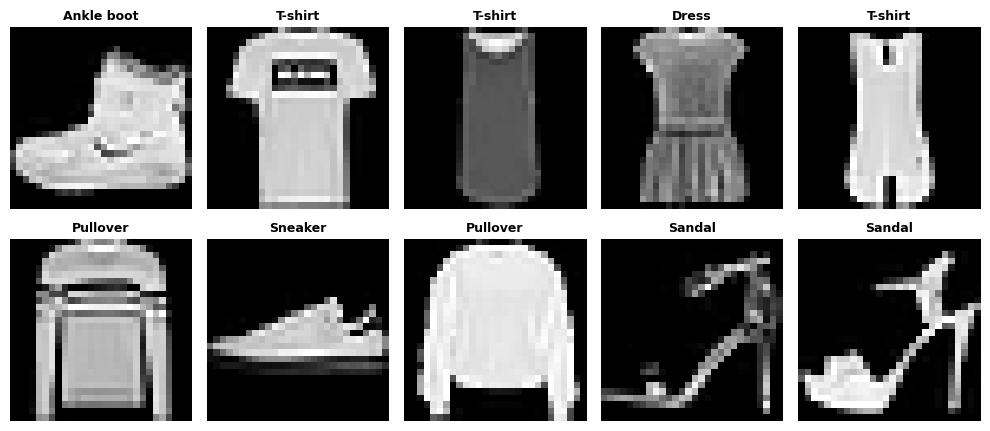

In [ ]:
plt.figure(figsize=(10, 4.5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_full[i], cmap="gray")
    plt.title(class_names[y_train_full[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.savefig("plots/sample_images.png", dpi=600, bbox_inches="tight")
plt.show()

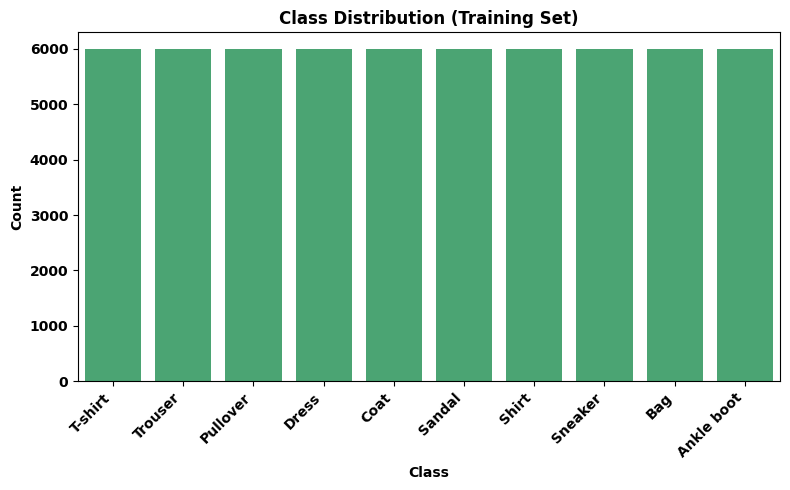

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_full, color="mediumseagreen")
plt.xticks(ticks=range(10), labels=class_names, rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Training Set)")
plt.tight_layout()
plt.savefig("plots/class_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

In [20]:
print("Before preprocessing:", X_train_full.shape)

# flatten the 28x28 images into a single 784-length vector, dense layers want 1D input
X_train_full_flat = X_train_full.reshape(len(X_train_full), 784).astype("float32")
X_test_flat = X_test.reshape(len(X_test), 784).astype("float32")

# pixels are 0-255, scale down to 0-1
X_train_full_flat /= 255.0
X_test_flat /= 255.0

print("After preprocessing :", X_train_full_flat.shape)

# one-hot encode the labels since we're using softmax + categorical cross entropy
y_train_full_oh = keras.utils.to_categorical(y_train_full, num_classes=10)
y_test_oh = keras.utils.to_categorical(y_test, num_classes=10)

print("Labels before one-hot:", y_train_full.shape)
print("Labels after one-hot :", y_train_full_oh.shape)

Before preprocessing: (60000, 28, 28)
After preprocessing : (60000, 784)
Labels before one-hot: (60000,)
Labels after one-hot : (60000, 10)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full_flat, y_train_full_oh, test_size=0.2,random_state=RANDOM_STATE, stratify=y_train_full)

print("Training samples  :", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples   :", X_test_flat.shape[0])

Training samples  : 48000
Validation samples: 12000
Testing samples   : 10000


In [21]:
def build_baseline_model():
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential_77"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_220 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_221 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_222 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
baseline_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

start = time.time()
history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32)
baseline_train_time = time.time() - start

print("Baseline training took", round(baseline_train_time, 1), "seconds")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8132 - loss: 0.5234 - val_accuracy: 0.8416 - val_loss: 0.4324
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8599 - loss: 0.3830 - val_accuracy: 0.8608 - val_loss: 0.3760
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8720 - loss: 0.3430 - val_accuracy: 0.8687 - val_loss: 0.3536
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8819 - loss: 0.3166 - val_accuracy: 0.8827 - val_loss: 0.3279
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8890 - loss: 0.2977 - val_accuracy: 0.8827 - val_loss: 0.3266
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8958 - loss: 0.2796 - val_accuracy: 0.8863 - val_loss: 0.3203
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9004 - loss: 0.2658 - val_accuracy: 0.8897 - val_loss: 0.3213
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9056 - loss: 0.2547 - 

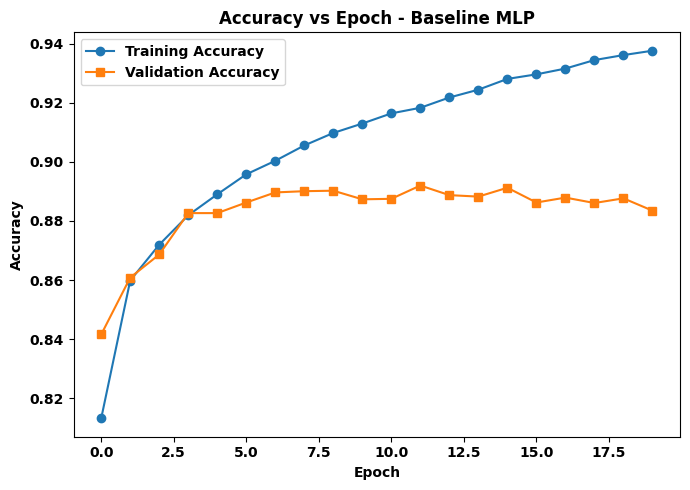

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="s", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch - Baseline MLP")
plt.legend(prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/accuracy_vs_epoch.png", dpi=600, bbox_inches="tight")
plt.show()

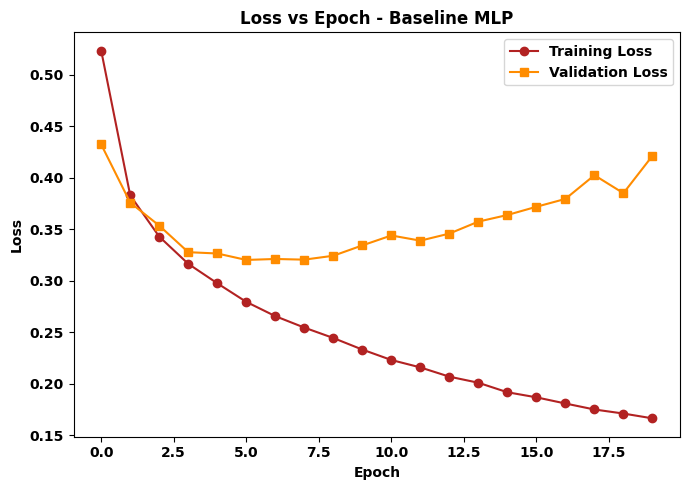

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], marker="o", color="firebrick", label="Training Loss")
plt.plot(history.history["val_loss"], marker="s", color="darkorange", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch - Baseline MLP")
plt.legend(prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/loss_vs_epoch.png", dpi=600, bbox_inches="tight")
plt.show()

In [25]:
y_pred_baseline = np.argmax(baseline_model.predict(X_test_flat), axis=1)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, average="macro")
baseline_recall = recall_score(y_test, y_pred_baseline, average="macro")
baseline_f1 = f1_score(y_test, y_pred_baseline, average="macro")

print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1-Score :", round(baseline_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_baseline, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8756
Precision: 0.8768
Recall   : 0.8756
F1-Score : 0.8753

Classification Report:
              precision    recall  f1-score   support

     T-shirt       0.84      0.81      0.83      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.73      0.86      0.79      1000
       Dress       0.90      0.86      0.88      1000
        Coat       0.80      0.79      0.79      1000
      Sandal       0.94      0.97      0.95      1000
       Shirt       0.71      0.65      0.68      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.98      0.91      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



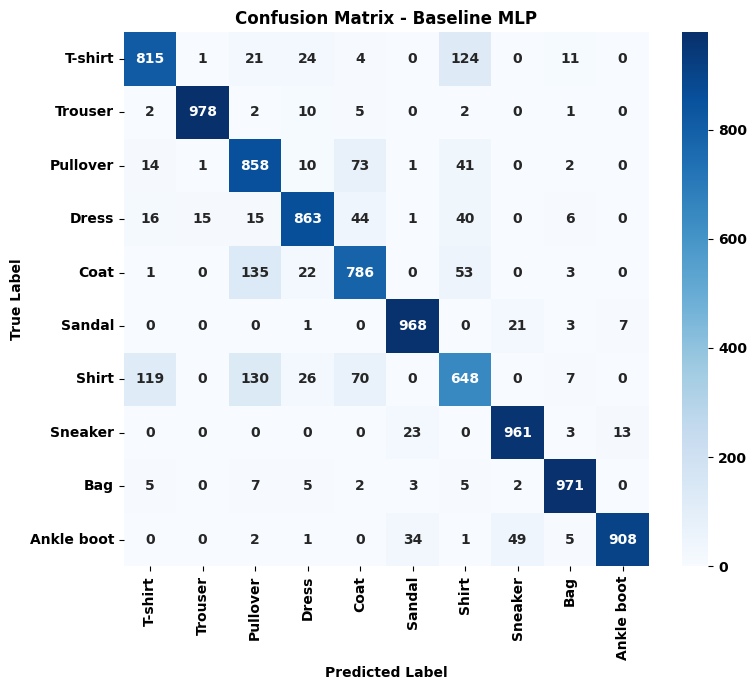

In [ ]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(8, 7))
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Baseline MLP")
plt.tight_layout()
plt.savefig("plots/confusion_matrix_baseline.png", dpi=600, bbox_inches="tight")
plt.show()

In [27]:
def build_tunable_model(hidden_layers=1, hidden_neurons=128, learning_rate=0.001,
                         activation="relu", dropout_rate=0.0, optimizer_name="adam"):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation="softmax"))

    if optimizer_name == "sgd":
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model


keras_clf = KerasClassifier(
    model=build_tunable_model,
    hidden_layers=1,
    hidden_neurons=128,
    learning_rate=0.001,
    activation="relu",
    dropout_rate=0.0,
    optimizer_name="adam",
    epochs=10,
    batch_size=32,
    verbose=0
)

param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "model__optimizer_name": ["sgd", "adam", "rmsprop"],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30]
}

In [28]:
random_search = RandomizedSearchCV(
    estimator=keras_clf,
    param_distributions=param_dist,
    n_iter=15,
    cv=5,
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=1)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'batch_size': [16, 32, ...], 'epochs': [10, 20, ...], 'model__activation': ['relu', 'tanh', ...], 'model__dropout_rate': [0.0, 0.2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function wh

In [29]:
best_params = random_search.best_params_

print("Best hyperparameters found:")
for key, value in best_params.items():
    print(" ", key, "=", value)

print("\nBest cross-validation accuracy:", round(random_search.best_score_, 4))

Best hyperparameters found:
  model__optimizer_name = adam
  model__learning_rate = 0.001
  model__hidden_neurons = 256
  model__hidden_layers = 1
  model__dropout_rate = 0.2
  model__activation = tanh
  epochs = 20
  batch_size = 64

Best cross-validation accuracy: 0.8855


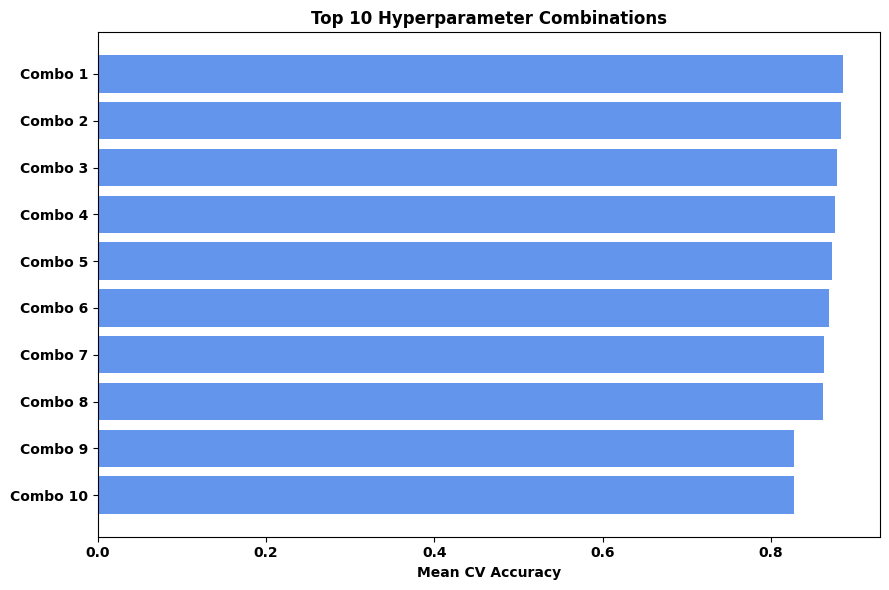

In [ ]:
results_df = pd.DataFrame(random_search.cv_results_)
top_results = results_df.sort_values("mean_test_score", ascending=False).head(10).reset_index(drop=True)

plt.figure(figsize=(9, 6))
plt.barh(range(len(top_results)), top_results["mean_test_score"], color="cornflowerblue")
plt.yticks(range(len(top_results)), [f"Combo {i+1}" for i in range(len(top_results))])
plt.xlabel("Mean CV Accuracy")
plt.title("Top 10 Hyperparameter Combinations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("plots/hyperparameter_search_results.png", dpi=600, bbox_inches="tight")
plt.show()

In [31]:
optimized_model = build_tunable_model(
    hidden_layers=best_params["model__hidden_layers"],
    hidden_neurons=best_params["model__hidden_neurons"],
    learning_rate=best_params["model__learning_rate"],
    activation=best_params["model__activation"],
    dropout_rate=best_params["model__dropout_rate"],
    optimizer_name=best_params["model__optimizer_name"])

start = time.time()
optimized_history = optimized_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"])
optimized_train_time = time.time() - start

print("Optimized model training took", round(optimized_train_time, 1), "seconds")

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8046 - loss: 0.5452 - val_accuracy: 0.8492 - val_loss: 0.4157
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8463 - loss: 0.4255 - val_accuracy: 0.8635 - val_loss: 0.3775
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8566 - loss: 0.3910 - val_accuracy: 0.8648 - val_loss: 0.3693
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8656 - loss: 0.3687 - val_accuracy: 0.8684 - val_loss: 0.3585
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8697 - loss: 0.3513 - val_accuracy: 0.8726 - val_loss: 0.3472
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8751 - loss: 0.3390 - val_accuracy: 0.8773 - val_loss: 0.3381
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8786 - loss: 0.3284 - val_accuracy: 0.8793 - val_loss: 0.3263
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8811 - loss: 0.3215 - val_accuracy: 0.

In [32]:
y_pred_optimized = np.argmax(optimized_model.predict(X_test_flat), axis=1)

optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
optimized_precision = precision_score(y_test, y_pred_optimized, average="macro")
optimized_recall = recall_score(y_test, y_pred_optimized, average="macro")
optimized_f1 = f1_score(y_test, y_pred_optimized, average="macro")

print("Accuracy :", round(optimized_accuracy, 4))
print("Precision:", round(optimized_precision, 4))
print("Recall   :", round(optimized_recall, 4))
print("F1-Score :", round(optimized_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimized, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8794
Precision: 0.8829
Recall   : 0.8794
F1-Score : 0.8805

Classification Report:
              precision    recall  f1-score   support

     T-shirt       0.87      0.80      0.83      1000
     Trouser       0.98      0.97      0.98      1000
    Pullover       0.78      0.80      0.79      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.81      0.76      0.78      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.65      0.74      0.69      1000
     Sneaker       0.92      0.97      0.94      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



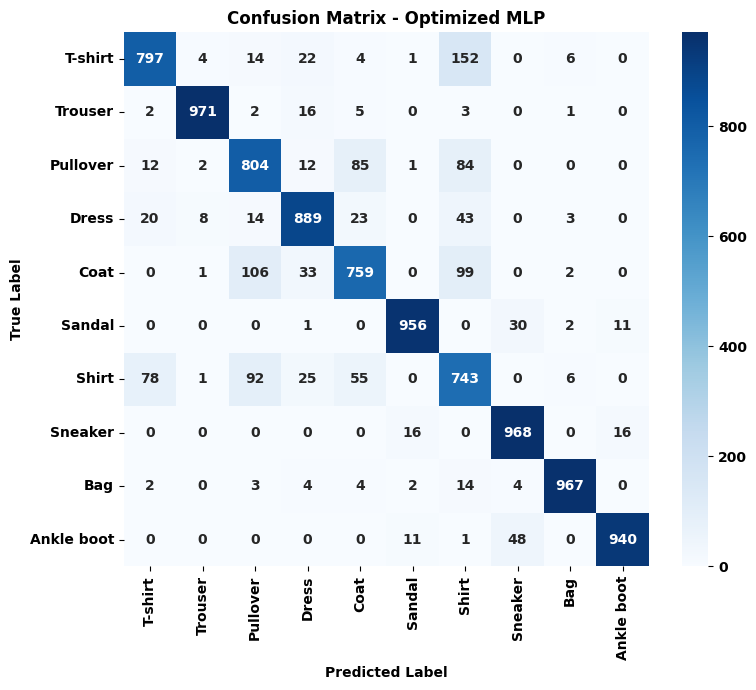

In [ ]:
cm_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(8, 7))
sns.heatmap(cm_optimized, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Optimized MLP")
plt.tight_layout()
plt.savefig("plots/confusion_matrix_optimized.png", dpi=600, bbox_inches="tight")
plt.show()

In [34]:
comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Training Time (s)"],
    "Baseline MLP": [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, baseline_train_time],
    "Optimized MLP": [optimized_accuracy, optimized_precision, optimized_recall, optimized_f1, optimized_train_time],
})
comparison_table

,Metric,Baseline MLP,Optimized MLP
0,Accuracy,0.875600,0.879400
1,Precision,0.876761,0.882909
2,Recall,0.875600,0.879400
3,F1-score,0.875319,0.880471
4,Training Time (s),115.234573,50.545758


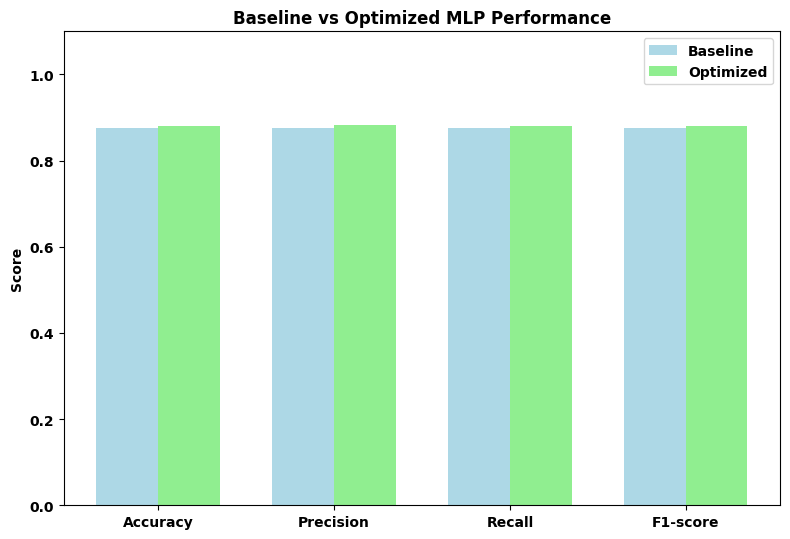

In [ ]:
metrics_only = comparison_table[comparison_table["Metric"] != "Training Time (s)"]
x_pos = np.arange(len(metrics_only))
bar_width = 0.35

plt.figure(figsize=(8, 5.5))
plt.bar(x_pos - bar_width/2, metrics_only["Baseline MLP"], bar_width, label="Baseline", color="lightblue")
plt.bar(x_pos + bar_width/2, metrics_only["Optimized MLP"], bar_width, label="Optimized", color="lightgreen")
plt.xticks(x_pos, metrics_only["Metric"])
plt.ylabel("Score")
plt.title("Baseline vs Optimized MLP Performance")
plt.ylim(0, 1.1)
plt.legend(prop={"weight": "bold"})
plt.tight_layout()
plt.savefig("plots/baseline_vs_optimized.png", dpi=600, bbox_inches="tight")
plt.show()